# Cannabis seed shape: does self-pollination reduce shape variability? — minimal reproduction

**Paper:** Self-pollinated cannabis seeds lead to less variation in shape: a technological approach of potential commercial interest.
DOI: [10.1186/s12870-025-07989-3](https://doi.org/10.1186/s12870-025-07989-3) (BMC Plant Biology, 2025).

**Author code:** [Francisco-ft/Self-pollinated-cannabis-seeds-lead-to-less-variation-in-shape](https://github.com/Francisco-ft/Self-pollinated-cannabis-seeds-lead-to-less-variation-in-shape) @ commit `033a3697c487df6438596a2772ad81dadbdb1653` (pinned).

**Scope of this notebook (minimal reproduction):** the *supervised classification* subsection of the paper —
train the four scikit-learn classifiers used by the authors (QDA, Random Forest, Decision Tree, Gaussian Naive Bayes)
on the released 713-seed × 26-coordinate dataset, reproduce the accuracy table and normalized confusion matrices for
all 7 cultivars and for the 5-cultivar variant (excluding `H` and `K`), and reproduce the per-cultivar PC1/PC2
variability comparison from `02-variability.ipynb`. It ends with an input preview (seed outlines and cultivar
distribution) rendered from the actual released coordinates.

**Not reproduced (documented omission):** the desktop-software stages of the paper — TPS landmark digitization,
Procrustes sliding in TpsRelw/MorphoJ, InfoStat clustering, seed imaging and size/allometry analysis — are not
scripted in the author repository and are out of scope. No pretrained weights exist; all classifiers are trained
from scratch, exactly as the authors did.

**実行内容（日本語）:** 著者公開の713種子・26座標データを用い、論文の教師あり分類実験（QDA / ランダムフォレスト / 決定木 / ナイーブベイズ、および GridSearchCV で最適化したランダムフォレスト）を7品種と5品種（H・K除外）の両方で再実行し、精度表・混同行列・PC1/PC2 変異性ヒートマップを再現します。TPS計測やProcrustes/クラスタリング等のデスクトップソフト工程は対象外です。

**Expected result:** optimized Random Forest ≈ 70% test accuracy (7 cultivars) and ≈ 78% (5 cultivars), matching the paper's reported values up to library-version variation.


In [ ]:
import sys
import numpy, pandas, sklearn, matplotlib, seaborn

print("Python:", sys.version.split()[0])
for m in (numpy, pandas, sklearn, matplotlib, seaborn):
    print(m.__name__, m.__version__)

Python: 3.13.15
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
matplotlib 3.10.0
seaborn 0.13.2


## 0. Runtime selection — CPU

This notebook needs **no GPU**. The dataset is tiny (713 seeds × 26 features) and all models are classical
scikit-learn estimators; the GridSearchCV step is ~108 candidate fits × 5-fold CV on ~500×26 data, which takes
seconds on CPU. Select **Runtime → Change runtime type → CPU** (the default) and **Runtime → Run all**.
Expected end-to-end time: under ~5 minutes including download.

**実行環境（日本語）:** GPUは不要です。ランタイムタイプはCPUのままで「すべてのセルを実行」してください。全体で5分程度です。


In [ ]:
import hashlib
import urllib.request

RAW_URL = "https://raw.githubusercontent.com/Francisco-ft/Self-pollinated-cannabis-seeds-lead-to-less-variation-in-shape/033a3697c487df6438596a2772ad81dadbdb1653/data/raw_coordinates.txt"
EXPECTED_BLOB_SHA1 = "bc71a5693f5b48303425373d6ad120b1a76da6f1"
EXPECTED_ROWS = 713

raw_bytes = urllib.request.urlopen(RAW_URL, timeout=60).read()
blob_sha1 = hashlib.sha1(b"blob %d\0" % len(raw_bytes) + raw_bytes).hexdigest()
assert blob_sha1 == EXPECTED_BLOB_SHA1, f"blob SHA-1 mismatch: {blob_sha1}"

with open("/content/raw_coordinates.txt", "wb") as f:
    f.write(raw_bytes)

n_rows = raw_bytes.decode("utf-8").strip().count("\n")
print(f"Downloaded {len(raw_bytes)} bytes from pinned commit 033a3697c487")
print(f"Git blob SHA-1 verified: {blob_sha1}")
print(f"Rows (excluding header): {n_rows} (expected {EXPECTED_ROWS})")
assert n_rows == EXPECTED_ROWS

Downloaded 349959 bytes from pinned commit 033a3697c487
Git blob SHA-1 verified: bc71a5693f5b48303425373d6ad120b1a76da6f1
Rows (excluding header): 713 (expected 713)


## 1. Environment

The scientific stack used here (pandas, numpy, scikit-learn, matplotlib, seaborn) is preinstalled on Colab.
This cell only prints the versions actually used, so the run is reproducible and any version drift is visible.

**実行内容（日本語）:** Colabにプレインストール済みのライブラリ版本を表示し、再現性を確認します。

In [ ]:
import pandas as pd

data = pd.read_csv("/content/raw_coordinates.txt", sep="\t")

print("Shape:", data.shape)
print("Columns:", list(data.columns))
print()
print("Cultivar value counts:")
print(data["Cultivar"].value_counts())
data.head()

Shape: (713, 28)
Columns: ['Id', 'Cultivar', 'RawCoord1', 'RawCoord2', 'RawCoord3', 'RawCoord4', 'RawCoord5', 'RawCoord6', 'RawCoord7', 'RawCoord8', 'RawCoord9', 'RawCoord10', 'RawCoord11', 'RawCoord12', 'RawCoord13', 'RawCoord14', 'RawCoord15', 'RawCoord16', 'RawCoord17', 'RawCoord18', 'RawCoord19', 'RawCoord20', 'RawCoord21', 'RawCoord22', 'RawCoord23', 'RawCoord24', 'RawCoord25', 'RawCoord26']

Cultivar value counts:
Cultivar
Ma    129
Me    104
K      99
F      97
H      97
L      96
P      91
Name: count, dtype: int64


,Id,Cultivar,RawCoord1,RawCoord2,RawCoord3,RawCoord4,RawCoord5,RawCoord6,RawCoord7,RawCoord8,...,RawCoord17,RawCoord18,RawCoord19,RawCoord20,RawCoord21,RawCoord22,RawCoord23,RawCoord24,RawCoord25,RawCoord26
0,1,F,-0.107060,0.302365,-0.043765,-0.303194,0.150788,0.297623,-0.183509,0.212267,...,0.081181,-0.276038,0.171228,-0.183809,0.239935,-0.054884,0.261457,0.085816,0.222029,0.199102
1,2,F,-0.078265,0.316076,-0.044971,-0.321985,0.126065,0.298730,-0.151797,0.220278,...,0.076402,-0.284889,0.165865,-0.183911,0.232688,-0.047941,0.249199,0.096149,0.204247,0.207747
2,3,F,-0.085017,0.297562,-0.056781,-0.309981,0.140202,0.318078,-0.167134,0.208089,...,0.072459,-0.289701,0.165713,-0.186963,0.245765,-0.052562,0.255675,0.096455,0.201534,0.216055
3,4,F,-0.077393,0.313264,-0.045949,-0.321746,0.121797,0.309324,-0.161015,0.225776,...,0.077239,-0.286195,0.171168,-0.186981,0.246732,-0.061465,0.242042,0.084444,0.186239,0.205576
4,5,F,-0.072001,0.307274,-0.052782,-0.327913,0.137427,0.320371,-0.146519,0.206527,...,0.063121,-0.296466,0.150161,-0.187751,0.227213,-0.045168,0.245820,0.108045,0.203917,0.226438


## 2. Minimal input: released raw landmark coordinates

**Provenance:** `data/raw_coordinates.txt` from the author repository, downloaded from the pinned commit
`033a3697c487df6438596a2772ad81dadbdb1653` (one tab-separated table: 713 seed rows with 26 raw coordinate columns plus cultivar labels).
This is the *only* data file required. The cell verifies the exact bytes with the Git blob SHA-1
(`sha1("blob <size>\0" + content)`), which must equal the repository's recorded blob hash
`bc71a5693f5b48303425373d6ad120b1a76da6f1`, and checks the row count.

**実行内容（日本語）:** 論文著者リポジトリの固定コミットから生のランドマーク座標ファイル `raw_coordinates.txt`（713種子）をColab内にダウンロードし、Git blob SHA-1 と行数で完全性を検証します。

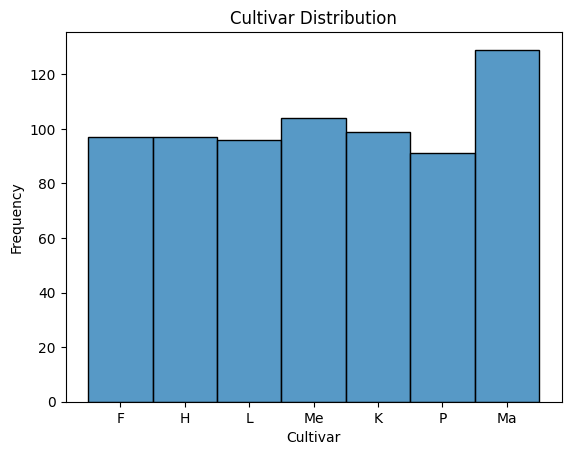

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("fig_all", exist_ok=True)

sns.histplot(data["Cultivar"])
plt.title("Cultivar Distribution")
plt.xlabel("Cultivar")
plt.ylabel("Frequency")
plt.savefig("fig_all/cultivar_distribution.png", dpi=300)
plt.show()

## 3. Load and inspect the dataset

The authors load the table with tab separation and use `data.columns[2:]` as the 26 coordinate features and
`Cultivar` as the target. The table therefore also carries two leading non-feature columns. This cell prints the
shape, column names, and the actual cultivar labels present in the released file — the labels observed here are
authoritative; the repository README's cultivar list (`Fr, H, K, Le, Ma, Me, Pa`) is checked against them.

**実行内容（日本語）:** データを読み込み、行数・列名・品種ラベルの実値を確認します（READMEの表記との差異も確認）。

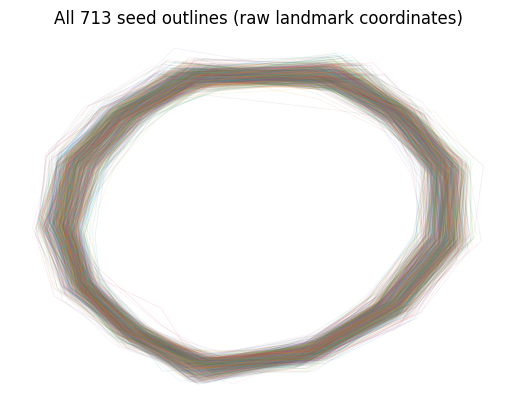

In [ ]:
import numpy as np

coords = data[data.columns[2:]].to_numpy()
coords = coords.reshape(713, 13, 2)
new_order = [0, 2, 12, 11, 10, 9, 8, 1, 7, 6, 5, 4, 3]  # authors' landmark order
coords_reordered = coords[:, new_order, :]

for i in range(coords_reordered.shape[0]):
    pts = coords_reordered[i]
    closed = np.vstack([pts, pts[0]])  # close the outline
    plt.plot(closed[:, 0], closed[:, 1], linewidth=0.6, alpha=0.1)
plt.axis(False)
plt.title("All 713 seed outlines (raw landmark coordinates)")
plt.savefig("fig_all/seed_outlines.png", dpi=300)
plt.show()

## 4. Input preview 1: cultivar distribution

Histogram of the 7 cultivar classes (reproducing `fig_all/cultivar_distribution.png` from the authors'
`00-dataset.ipynb`). This shows the class balance of the 713 seeds before any modeling.

**実行内容（日本語）:** 7品種の種子数のヒストグラムを表示します（著者の00-dataset.ipynbと同じ図）。

In [ ]:
from sklearn.model_selection import train_test_split

X_train_df, X_test_df = train_test_split(
    data, test_size=0.30, random_state=42, stratify=data["Cultivar"])

target_column = "Cultivar"
feature_columns = data.columns[2:]

x_train = X_train_df[feature_columns].to_numpy()
y_train = X_train_df[target_column].to_numpy()
x_test = X_test_df[feature_columns].to_numpy()
y_test = X_test_df[target_column].to_numpy()

print(f"Train set: {x_train.shape}, {y_train.shape}")
print(f"Test set: {x_test.shape}, {y_test.shape}")

Train set: (499, 26), (499,)
Test set: (214, 26), (214,)


## 5. Input preview 2: seed outlines

Each seed is described by 13 landmarks with (X, Y) coordinates. Exactly as in the authors' `00-dataset.ipynb`,
the 26 coordinate columns are reshaped to (713, 13, 2), reordered with the authors' landmark order
`[0, 2, 12, 11, 10, 9, 8, 1, 7, 6, 5, 4, 3]`, and drawn as closed translucent outlines. This previews the actual
input shapes the classifiers will learn from — no images are classified, only landmark coordinates.

**実行内容（日本語）:** 713個の種子輪郭を重ねて描画し、分類器が学習する実際の入力形状を確認します。

In [ ]:
def calc_confusion_matrix(y_test, y_pred_tuned, class_names, title, prefix="all"):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_test, y_pred_tuned, normalize="true")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title(title)
    save_file = title.replace(" ", "_")
    plt.savefig(f"fig_{prefix}/{save_file}.png", dpi=300)
    plt.show()

## 6. Train/test split — exactly as the authors did

The authors' `01-train.ipynb` splits with `test_size=0.30`, `random_state=42`, stratified by `Cultivar`
(the paper text does not restate this, but the released code fixes it, which makes the split reproducible).
Features are `data.columns[2:]` and the target is `Cultivar`.

**実行内容（日本語）:** 著者のコードどおり、層化70/30分割（random_state=42）を行います。

 TRAIN AND TEST: QDA
Accuracy: 0.6636

 Classification report:
              precision    recall  f1-score   support

           F       0.68      0.66      0.67        29
           H       0.38      0.45      0.41        29
           K       0.53      0.63      0.58        30
           L       0.61      0.59      0.60        29
          Ma       0.74      0.82      0.78        39
          Me       0.90      0.61      0.73        31
           P       0.96      0.85      0.90        27

    accuracy                           0.66       214
   macro avg       0.69      0.66      0.67       214
weighted avg       0.69      0.66      0.67       214



/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

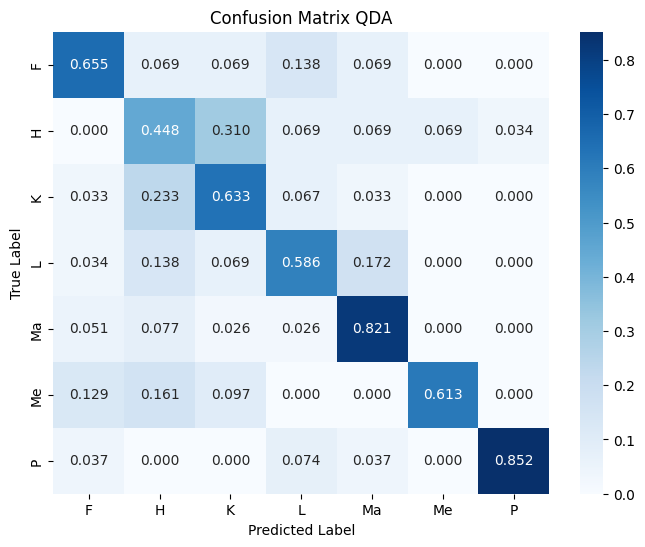

 TRAIN AND TEST: Random Forest


Accuracy: 0.6776

 Classification report:
              precision    recall  f1-score   support

           F       0.77      0.83      0.80        29
           H       0.43      0.34      0.38        29
           K       0.41      0.43      0.42        30
           L       0.69      0.69      0.69        29
          Ma       0.79      0.79      0.79        39
          Me       0.68      0.68      0.68        31
           P       0.90      0.96      0.93        27

    accuracy                           0.68       214
   macro avg       0.67      0.68      0.67       214
weighted avg       0.67      0.68      0.67       214



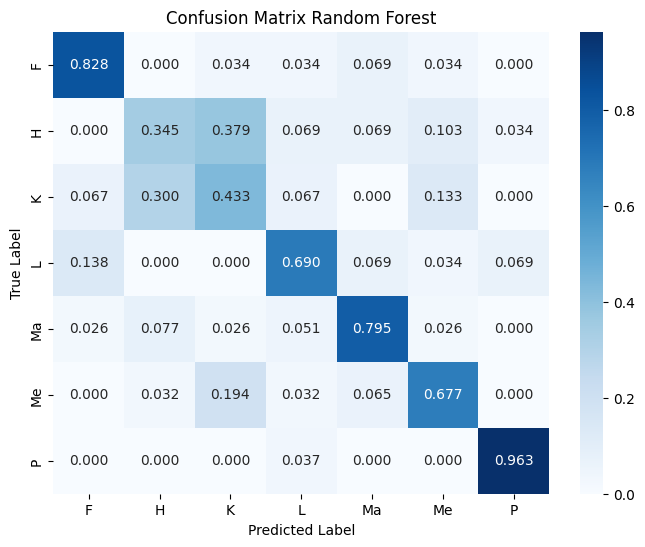

 TRAIN AND TEST: Decision Tree
Accuracy: 0.6262

 Classification report:
              precision    recall  f1-score   support

           F       0.68      0.79      0.73        29
           H       0.50      0.38      0.43        29
           K       0.41      0.40      0.41        30
           L       0.68      0.45      0.54        29
          Ma       0.59      0.77      0.67        39
          Me       0.73      0.77      0.75        31
           P       0.81      0.78      0.79        27

    accuracy                           0.63       214
   macro avg       0.63      0.62      0.62       214
weighted avg       0.62      0.63      0.62       214



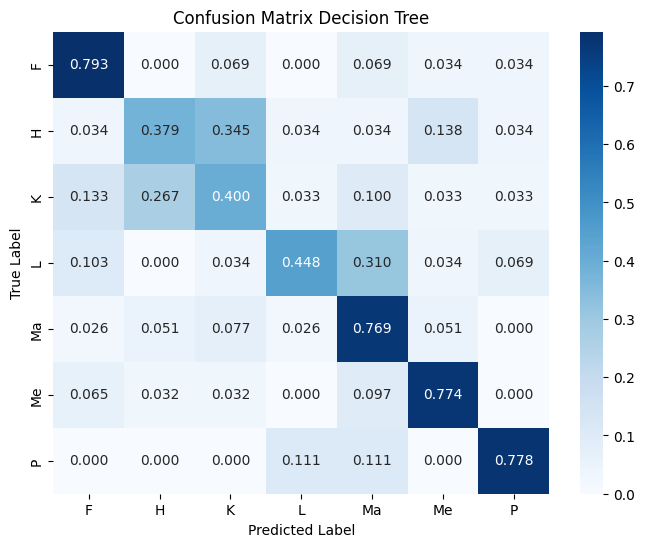

 TRAIN AND TEST: Naive Bayes (Gaussiano)
Accuracy: 0.6355

 Classification report:
              precision    recall  f1-score   support

           F       0.88      0.79      0.84        29
           H       0.24      0.14      0.17        29
           K       0.34      0.47      0.39        30
           L       0.78      0.62      0.69        29
          Ma       0.72      0.74      0.73        39
          Me       0.60      0.68      0.64        31
           P       0.84      1.00      0.92        27

    accuracy                           0.64       214
   macro avg       0.63      0.63      0.63       214
weighted avg       0.63      0.64      0.63       214



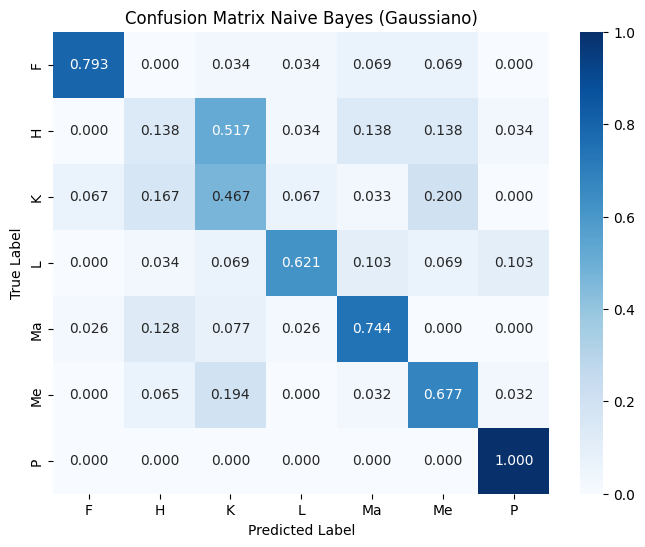

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

os.makedirs("fig_all", exist_ok=True)

classifiers = {
    "QDA": QuadraticDiscriminantAnalysis(),
    "Random Forest": RandomForestClassifier(max_depth=5, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Naive Bayes (Gaussiano)": GaussianNB(),
}

results_summary = pd.DataFrame(columns=["Classifier", "Test Accuracy"])

for name, clf in classifiers.items():
    print("=" * 45)
    print(f" TRAIN AND TEST: {name}")
    print("=" * 45)
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    test_accuracy = clf.score(x_test, y_test)
    print(f"Accuracy: {test_accuracy:.4f}")
    results_summary.loc[len(results_summary)] = [name, test_accuracy]
    print("\n Classification report:")
    print(classification_report(y_test, y_pred))
    calc_confusion_matrix(y_test, y_pred, clf.classes_, f"Confusion Matrix {name}")

## 7. Confusion-matrix helper (author's `utils.py`)

This is the authors' `calc_confusion_matrix` from `utils.py`, copied verbatim in behavior: a row-normalized
(`normalize='true'`) seaborn heatmap saved to `fig_all/`. It is inlined here so the notebook is self-contained
on Colab; the saved file name follows the authors' `title → filename` rule.

**実行内容（日本語）:** 著者の `utils.py` にある混同行列描画関数をそのまま再現します。

In [ ]:
print("=" * 45)
print(" RESUME ACCURACY")
print("=" * 45)
results_summary.sort_values(by="Test Accuracy", ascending=False).to_string(index=False)
results_summary.sort_values(by="Test Accuracy", ascending=False)

 RESUME ACCURACY


,Classifier,Test Accuracy
1,Random Forest,0.677570
0,QDA,0.663551
3,Naive Bayes (Gaussiano),0.635514
2,Decision Tree,0.626168


## 8. Train the four classifiers (7 cultivars)

Exactly the authors' `01-train.ipynb` configuration: QDA (default), Random Forest (`max_depth=5, random_state=42`),
Decision Tree (`max_depth=5, random_state=42`), and Gaussian Naive Bayes. For each model we print the test
accuracy and the full `classification_report` (precision/recall/F1 per cultivar), then draw the normalized
confusion matrix.

**実行内容（日本語）:** 著者と同じ4分類器を7品種で訓練・評価し、精度と混同行列を出力します。

In [ ]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(x_train, y_train)

print("Best params:")
print(grid_search.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


Best params:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}


## 9. Accuracy summary (7 cultivars)

Sorted test-accuracy table for the four baseline classifiers, as printed by the authors' notebook.

**実行内容（日本語）:** 4分類器のテスト精度を降順で一覧表示します。

Train accuracy: 1.0000
Test accuracy:  0.7009
              precision    recall  f1-score   support

           F       0.77      0.83      0.80        29
           H       0.44      0.41      0.43        29
           K       0.47      0.53      0.50        30
           L       0.73      0.66      0.69        29
          Ma       0.83      0.77      0.80        39
          Me       0.80      0.77      0.79        31
           P       0.83      0.93      0.88        27

    accuracy                           0.70       214
   macro avg       0.70      0.70      0.70       214
weighted avg       0.70      0.70      0.70       214



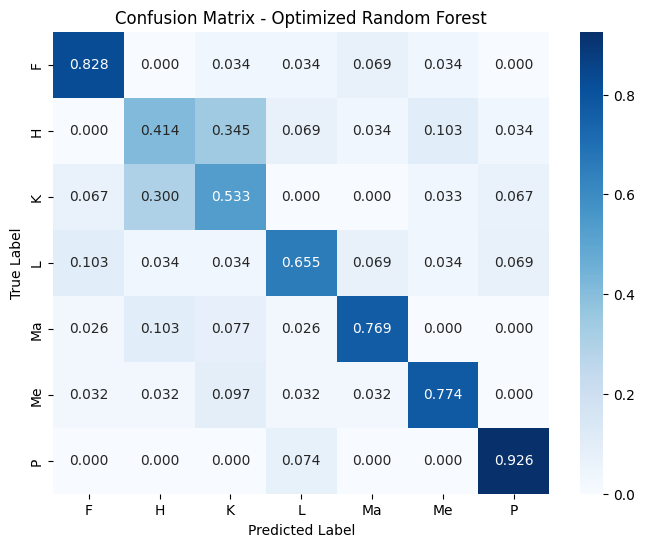

In [ ]:
best_rf = grid_search.best_estimator_

train_accuracy_tuned = best_rf.score(x_train, y_train)
test_accuracy_tuned = best_rf.score(x_test, y_test)
y_pred_tuned = best_rf.predict(x_test)

print(f"Train accuracy: {train_accuracy_tuned:.4f}")
print(f"Test accuracy:  {test_accuracy_tuned:.4f}")
print(classification_report(y_test, y_pred_tuned))

calc_confusion_matrix(y_test, y_pred_tuned, best_rf.classes_,
                      title="Confusion Matrix - Optimized Random Forest")

## 10. GridSearchCV: optimized Random Forest (7 cultivars)

The authors' full hyperparameter search: 108 candidates × 5-fold CV over `n_estimators`, `max_depth`,
`min_samples_leaf`, `min_samples_split`, `criterion` with `random_state=42`. The paper reports that the optimized
Random Forest reaches about 70% overall test accuracy on the 7-cultivar task; the best parameters found here are
compared against the paper's reported optimum (entropy, max_depth 15, n_estimators 150).

**実行内容（日本語）:** 著者と同じグリッドサーチでランダムフォレストを最適化します（論文報告値は約70%）。

In [ ]:
data_5 = data[[c in ["F", "L", "Me", "P", "Ma"] for c in data["Cultivar"]]]

print("Cultivars kept:", sorted(data_5["Cultivar"].unique()))
print("Rows kept:", len(data_5), "of", len(data))

X_train_5, X_test_5 = train_test_split(
    data_5, test_size=0.30, random_state=42, stratify=data_5["Cultivar"])

x_train5 = X_train_5[feature_columns].to_numpy()
y_train5 = X_train_5[target_column].to_numpy()
x_test5 = X_test_5[feature_columns].to_numpy()
y_test5 = X_test_5[target_column].to_numpy()

os.makedirs("fig_without_H_K", exist_ok=True)

classifiers5 = {
    "QDA": QuadraticDiscriminantAnalysis(),
    "Random Forest": RandomForestClassifier(max_depth=5, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Naive Bayes": GaussianNB(),
}

results_5 = pd.DataFrame(columns=["Classifier", "Test Accuracy"])
for name, clf in classifiers5.items():
    print("=" * 45)
    print(f" TRAIN AND TEST: {name}")
    print("=" * 45)
    clf.fit(x_train5, y_train5)
    y_pred5 = clf.predict(x_test5)
    acc5 = clf.score(x_test5, y_test5)
    print(f"Accuracy: {acc5:.4f}")
    results_5.loc[len(results_5)] = [name, acc5]
    print("\n Classification report:")
    print(classification_report(y_test5, y_pred5))

print(" SUMMARY (5 cultivars, baseline)")
results_5.sort_values(by="Test Accuracy", ascending=False)

Cultivars kept: ['F', 'L', 'Ma', 'Me', 'P']
Rows kept: 517 of 713
 TRAIN AND TEST: QDA
Accuracy: 0.7244

 Classification report:
              precision    recall  f1-score   support

           F       0.65      0.52      0.58        29
           L       0.53      0.79      0.64        29
          Ma       0.73      0.77      0.75        39
          Me       0.89      0.77      0.83        31
           P       0.95      0.75      0.84        28

    accuracy                           0.72       156
   macro avg       0.75      0.72      0.73       156
weighted avg       0.75      0.72      0.73       156

 TRAIN AND TEST: Random Forest


/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

Accuracy: 0.7692

 Classification report:
              precision    recall  f1-score   support

           F       0.75      0.83      0.79        29
           L       0.65      0.59      0.62        29
          Ma       0.78      0.82      0.80        39
          Me       0.81      0.84      0.83        31
           P       0.84      0.75      0.79        28

    accuracy                           0.77       156
   macro avg       0.77      0.76      0.76       156
weighted avg       0.77      0.77      0.77       156

 TRAIN AND TEST: Decision Tree
Accuracy: 0.6987

 Classification report:
              precision    recall  f1-score   support

           F       0.79      0.66      0.72        29
           L       0.49      0.59      0.53        29
          Ma       0.73      0.82      0.77        39
          Me       0.83      0.81      0.82        31
           P       0.70      0.57      0.63        28

    accuracy                           0.70       156
   macro avg    

,Classifier,Test Accuracy
1,Random Forest,0.769231
3,Naive Bayes,0.756410
0,QDA,0.724359
2,Decision Tree,0.698718


## 11. Evaluation of the optimized Random Forest (7 cultivars)

Test-set `classification_report` and the row-normalized confusion matrix of the best estimator
(`fig_all/Confusion_Matrix_-_Optimized_Random_Forest.png` in the authors' repository). Overall accuracy is
compared with the paper's ~70%.

**実行内容（日本語）:** 最適化ランダムフォレストのテスト精度・混同行列を表示します（論文の約70%と比較）。

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Test accuracy (5 cultivars): 0.7885
              precision    recall  f1-score   support

           F       0.75      0.83      0.79        29
           L       0.71      0.59      0.64        29
          Ma       0.78      0.82      0.80        39
          Me       0.81      0.84      0.83        31
           P       0.89      0.86      0.87        28

    accuracy                           0.79       156
   macro avg       0.79      0.79      0.79       156
weighted avg       0.79      0.79      0.79       156



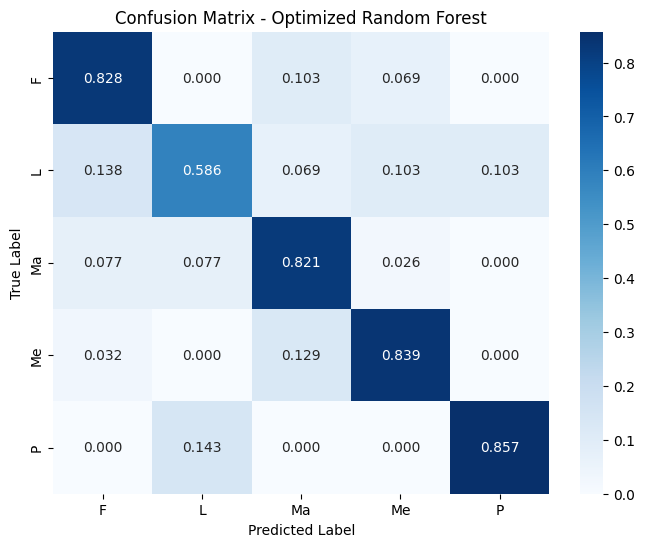

In [ ]:
grid_search5 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_search5.fit(x_train5, y_train5)
print("Best params:", grid_search5.best_params_)

best_rf5 = grid_search5.best_estimator_
print(f"Test accuracy (5 cultivars): {best_rf5.score(x_test5, y_test5):.4f}")
y_pred5_tuned = best_rf5.predict(x_test5)
print(classification_report(y_test5, y_pred5_tuned))

calc_confusion_matrix(y_test5, y_pred5_tuned, best_rf5.classes_,
                      title="Confusion Matrix - Optimized Random Forest", prefix="without_H_K")

## 12. Variant without H and K (5 cultivars)

The authors' `01-train-without-H-K.ipynb` removes two cultivars to test whether the hardest classes depress
accuracy, then reruns the same pipeline with the confusion matrix saved under `fig_without_H_K/`. The paper
reports ~78% test accuracy for the optimized Random Forest on this reduced task. We apply the authors' exact
filter list `['F', 'L', 'Me', 'P', 'Ma']` to the observed cultivar labels and print the classes actually kept
(the repository README's label spelling differs from the filter list; the released code and the data are
authoritative and the observed labels are shown above in section 3).

**実行内容（日本語）:** H・Kを除外した5品種で同じ実験を繰り返します（論文報告値は約78%）。著者コードのフィルタをそのまま使用します。

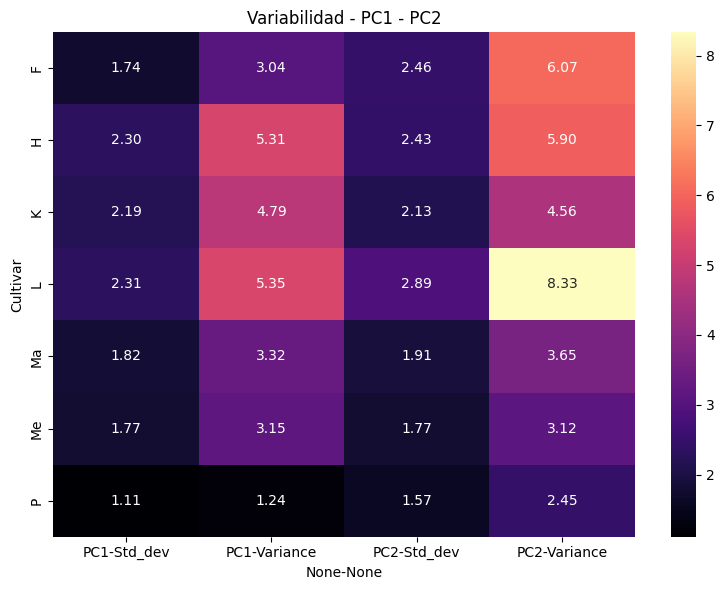

PC1                 PC2          
           Std_dev  Variance   Std_dev  Variance
Cultivar                                        
F         1.743088  3.038355  2.463867  6.070641
H         2.304090  5.308829  2.429904  5.904432
K         2.189336  4.793193  2.134807  4.557399
L         2.313321  5.351455  2.886664  8.332830
Ma        1.820960  3.315895  1.909478  3.646105
Me        1.774552  3.149036  1.765937  3.118532
P         1.112778  1.238276  1.565379  2.450412

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def indices_variabilidad_multi(df, grupo, variables):
    resultados = {}
    for var in variables:
        res = df.groupby(grupo)[var].agg(
            Std_dev=lambda x: x.std(ddof=1),
            Variance="var",
        )
        resultados[var] = res
    return pd.concat(resultados, axis=1)

vars_raw = [f"RawCoord{i}" for i in range(1, 27)]

df_test = X_test_df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_test[vars_raw])
pcs = PCA(n_components=2).fit_transform(X_scaled)
df_test["PC1"] = pcs[:, 0]
df_test["PC2"] = pcs[:, 1]

df_res = indices_variabilidad_multi(df_test, "Cultivar", ["PC1", "PC2"])
cols = [("PC1", "Std_dev"), ("PC1", "Variance"), ("PC2", "Std_dev"), ("PC2", "Variance")]

plt.figure(figsize=(8, 6))
sns.heatmap(df_res[cols], annot=True, fmt=".2f", cmap="magma")
plt.title("Variabilidad - PC1 - PC2")
plt.tight_layout()
plt.savefig("fig_all/variabilidad_PC1_PC2_heatmap.png", dpi=300)
plt.show()

df_res[cols]

## 13. GridSearchCV on the 5-cultivar variant

Same search space and settings as section 10, applied to the reduced dataset, followed by the evaluation and the
`fig_without_H_K` confusion matrix of the best estimator.

**実行内容（日本語）:** 5品種版でも同じグリッドサーチを行い、混同行列を表示します。

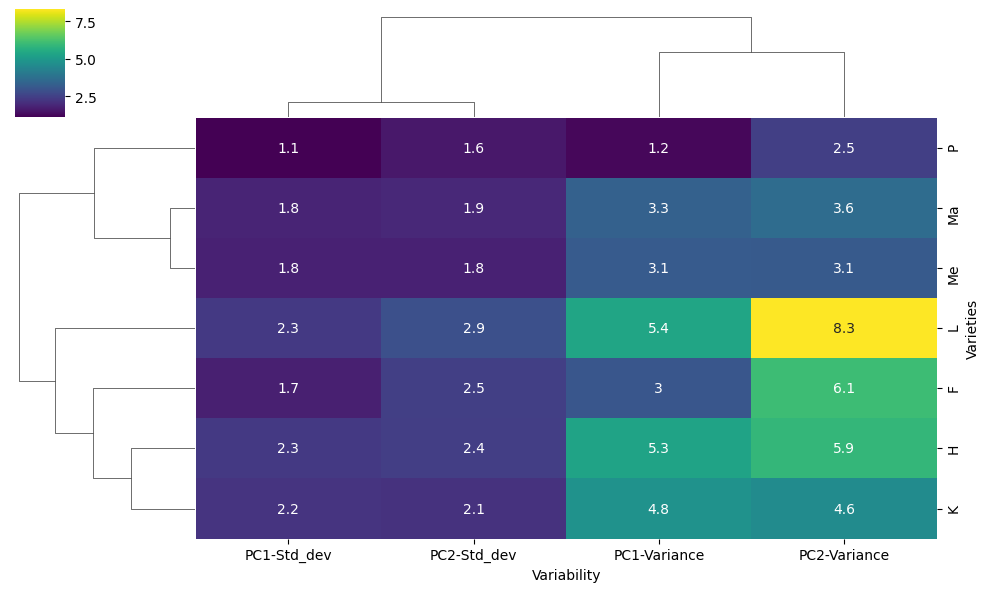

In [ ]:
axis = sns.clustermap(df_res[cols], cmap="viridis", figsize=(10, 6), annot=True)
axis.ax_heatmap.set_xlabel("Variability")
axis.ax_heatmap.set_ylabel("Varieties")
plt.savefig("fig_all/clustermap_variabilidad_PC1_PC2.png", dpi=300)
plt.show()